# Beam_FEM_Thermal_CCX — Complete Walkthrough

This notebook explains the entire project from physics to code, step by step.

**What this project does:**  
Train a neural network to replace expensive FEM simulations. Given a beam's material, heat load, and a query point in space, the network instantly predicts the temperature at that point — no solver needed.

---

## Table of Contents
1. [The Physical Problem](#1-the-physical-problem)
2. [The Dataset](#2-the-dataset)
3. [Data Loading & Inspection](#3-data-loading--inspection)
4. [Normalisation](#4-normalisation)
5. [The Neural Network Architecture](#5-the-neural-network-architecture)
6. [The Physics Loss](#6-the-physics-loss)
7. [The Training Loop](#7-the-training-loop)
8. [Inference & Results](#8-inference--results)
9. [Weaknesses & What to Improve](#9-weaknesses--what-to-improve)

---
## 1. The Physical Problem

We have a **cantilever beam** made of different materials:

```
         q (heat flux in)
         ↓↓↓↓↓↓↓↓↓↓↓↓↓↓
T=20°C ██████████████████  →  X
  fixed ←─────1000mm──────→
         100×100 mm cross-section
```

**Boundary conditions:**
- Left face (X=0): fixed temperature T = 20°C (Dirichlet)
- Right face (X=L): heat flux q applied (Neumann)
- Side walls: adiabatic — no heat escapes (natural BC, zero flux)

**Governing PDE** — steady-state heat conduction:

$$\nabla \cdot (k \nabla T) = 0$$

Since $k$ is uniform (constant material), this simplifies to the Laplace equation:

$$\nabla^2 T = \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} + \frac{\partial^2 T}{\partial z^2} = 0$$

**Analytical 1D solution** (useful sanity check):

$$T(x) = T_{fix} + \frac{q \cdot x}{k \cdot A}$$

The temperature rises linearly from the fixed end, with slope $q/(k \cdot A)$. Higher conductivity $k$ → smaller gradient (heat spreads easily). Higher flux $q$ → steeper gradient.

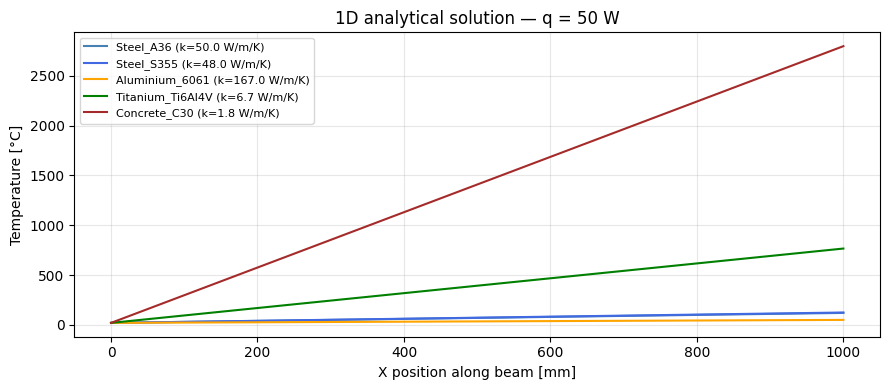

Max ΔT per material at q=50W:
  Steel_A36                  ΔT = 100.0 °C
  Steel_S355                 ΔT = 104.2 °C
  Aluminium_6061             ΔT = 29.9 °C
  Titanium_Ti6Al4V           ΔT = 746.3 °C
  Concrete_C30               ΔT = 2777.8 °C


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def set_axes_equal(ax):
    """Force equal aspect ratio in 3D matplotlib axes."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    spans  = limits[:, 1] - limits[:, 0]
    centers = limits.mean(axis=1)
    max_span = spans.max() / 2
    ax.set_xlim3d([centers[0] - max_span, centers[0] + max_span])
    ax.set_ylim3d([centers[1] - max_span, centers[1] + max_span])
    ax.set_zlim3d([centers[2] - max_span, centers[2] + max_span])

# Analytical 1D solution for sanity checks
L = 1000.0       # mm
A = 100.0 * 100.0  # mm²
T_fix = 20.0     # °C

x = np.linspace(0, L, 200)

MATERIALS = {
    'Steel_A36':        {'k': 50.0,  'color': 'steelblue'},
    'Steel_S355':       {'k': 48.0,  'color': 'royalblue'},
    'Aluminium_6061':   {'k': 167.0, 'color': 'orange'},
    'Titanium_Ti6Al4V': {'k': 6.7,   'color': 'green'},
    'Concrete_C30':     {'k': 1.8,   'color': 'brown'},
}

q = 50_000.0  # mW

fig, ax = plt.subplots(figsize=(9, 4))
for mat, props in MATERIALS.items():
    T = T_fix + q * x / (props['k'] * A)
    ax.plot(x, T, label=f"{mat} (k={props['k']} W/m/K)", color=props['color'])

ax.set_xlabel('X position along beam [mm]')
ax.set_ylabel('Temperature [°C]')
ax.set_title(f'1D analytical solution — q = {q/1000:.0f} W')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Max ΔT per material at q=50W:")
for mat, props in MATERIALS.items():
    dT = q * L / (props['k'] * A)
    print(f"  {mat:<25}  ΔT = {dT:.1f} °C")

---
## 2. The Dataset

### Why not just use the analytical solution?

The 3D FEM solution is needed because:
- Real geometries are not 1D bars
- The neural network must learn the **full 3D field** T(x,y,z)
- The PINN approach generalises to arbitrary geometries where no analytical solution exists

### Case sweep design

| Parameter | Values |
|-----------|--------|
| Materials | 5 (Steel A36/S355, Aluminium, Titanium, Concrete) |
| Q train   | 100 log-spaced values, 500–100,000 mW |
| Q test    | 5 values: 100, 300, 52,500, 200,000, 500,000 mW |
| T_fix     | 20°C (fixed) |
| **Total** | **525 cases** (500 train + 25 test) |

### Why log-spaced Q?

Conductivity spans **90×** across materials (1.8 to 167 W/m/K).  
For the same Q, Concrete gets ~90× hotter than Aluminium.  
Log-spacing ensures every material sees a wide, balanced range of temperature gradients.

### Why these test Q values?

- **100, 300 mW** → below training range (extrapolation downward)
- **52,500 mW** → middle of training range (interpolation)
- **200,000, 500,000 mW** → above training range (extrapolation upward)

This tests both interpolation accuracy and extrapolation failure modes.

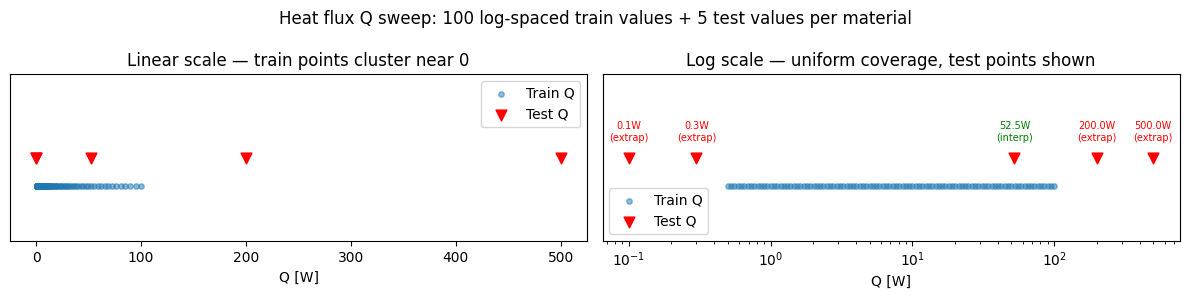

In [8]:
# Visualise the Q sweep design
Q_MIN, Q_MAX = 500.0, 100_000.0
N_Q = 100
Q_TEST = [100.0, 300.0, 52_500.0, 200_000.0, 500_000.0]

q_train = np.logspace(np.log10(Q_MIN), np.log10(Q_MAX), N_Q)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Linear scale
axes[0].scatter(q_train / 1000, np.ones_like(q_train), s=15, alpha=0.5, label='Train Q')
axes[0].scatter([q / 1000 for q in Q_TEST], np.ones(5) * 1.1, s=60,
                marker='v', color='red', label='Test Q', zorder=5)
axes[0].set_xlabel('Q [W]')
axes[0].set_title('Linear scale — train points cluster near 0')
axes[0].legend()
axes[0].set_ylim(0.8, 1.4)
axes[0].set_yticks([])

# Log scale
axes[1].scatter(q_train / 1000, np.ones_like(q_train), s=15, alpha=0.5, label='Train Q')
axes[1].scatter([q / 1000 for q in Q_TEST], np.ones(5) * 1.1, s=60,
                marker='v', color='red', label='Test Q', zorder=5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Q [W]')
axes[1].set_title('Log scale — uniform coverage, test points shown')
axes[1].legend()
axes[1].set_ylim(0.8, 1.4)
axes[1].set_yticks([])

# Annotate test points
for q in Q_TEST:
    label = 'interp' if Q_MIN <= q <= Q_MAX else 'extrap'
    color = 'green' if label == 'interp' else 'red'
    axes[1].annotate(f'{q/1000:.1f}W\n({label})', (q/1000, 1.1),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=7, color=color)

plt.suptitle('Heat flux Q sweep: 100 log-spaced train values + 5 test values per material')
plt.tight_layout()
plt.show()

---
## 3. Data Loading & Inspection

### What each case contains

```
elmer_cases/thermal_ccx_beam/case_0042/
├── case.sif           ← Elmer input (generated by script 03)
├── case_params.json   ← q, k, T_fix, material, split
├── case0001.vtu       ← Elmer output (unstructured VTK)
└── case.vtk           ← converted legacy VTK (used by train.py)
```

The VTK file contains:
- **Mesh points**: ~10,000 nodes with (x, y, z) coordinates
- **Point data**: `temperature` field — one value per node

The feature matrix for one case is assembled as:

```python
X = [ x, y, z,  q_total_mW,  k,  T_fix ]   # shape: (N_nodes, 6)
Y = [ T ]                                    # shape: (N_nodes, 1)
```

The same `q, k, T_fix` values are **tiled** across all nodes of a case — they are global case parameters, not per-node.

In [9]:
import json
from pathlib import Path
import meshio

ROOT = Path('..').resolve()
CASES_DIR = ROOT / 'elmer_cases' / 'thermal_ccx_beam'
MANIFEST = CASES_DIR / 'vtk_manifest.json'

MATERIAL_K = {
    'Steel_A36': 50.0, 'Steel_S355': 48.0,
    'Aluminium_6061': 167.0, 'Titanium_Ti6Al4V': 6.7, 'Concrete_C30': 1.8,
}

manifest = json.loads(MANIFEST.read_text())
entries = [e for e in manifest['cases'] if e.get('success')]

print(f"Total cases in manifest : {len(manifest['cases'])}")
print(f"Successful cases        : {len(entries)}")
print(f"Train                   : {sum(1 for e in entries if e.get('split') == 'train')}")
print(f"Test                    : {sum(1 for e in entries if e.get('split') == 'test')}")

Total cases in manifest : 525
Successful cases        : 525
Train                   : 500
Test                    : 25


In [10]:
# Inspect one case in detail
entry = entries[42]
vtk_path = CASES_DIR / entry['vtk']
params_path = vtk_path.parent / 'case_params.json'
params = json.loads(params_path.read_text())

mesh = meshio.read(str(vtk_path))
coords = mesh.points  # (N, 3)
temp_key = next(k for k in mesh.point_data if k.lower() == 'temperature')
T_field = mesh.point_data[temp_key].squeeze()

print(f"Case : {entry['case_id']}")
print(f"Params: {params}")
print()
print(f"Mesh nodes : {len(coords):,}")
print(f"Coord range X: {coords[:,0].min():.1f} → {coords[:,0].max():.1f} mm")
print(f"Coord range Y: {coords[:,1].min():.1f} → {coords[:,1].max():.1f} mm")
print(f"Coord range Z: {coords[:,2].min():.1f} → {coords[:,2].max():.1f} mm")
print()
print(f"T min  : {T_field.min():.4f} °C")
print(f"T max  : {T_field.max():.4f} °C")
print(f"T mean : {T_field.mean():.4f} °C")

# Sanity check vs analytical
k = MATERIAL_K[params['material']]
q = params['q_total_mW']
A = 100.0 * 100.0
L = 1000.0
dT_analytical = q * L / (k * A)
print(f"\nAnalytical ΔT  : {dT_analytical:.4f} °C")
print(f"FEM ΔT         : {T_field.max() - 20.0:.4f} °C")
print(f"Match          : {'✓' if abs(dT_analytical - (T_field.max() - 20.0)) < 1.0 else '✗'}")

Case : case_0042
Params: {'case_id': 'case_0042', 'q_total_mW': 4733.305631538583, 'T_fix_C': 20.0, 'T_init_C': 20.0, 'material': 'Steel_A36', 'k_mW_mm_C': 50.0, 'alpha_th_per_C': 1.2e-05, 'split': 'train'}

Mesh nodes : 9,314
Coord range X: 0.0 → 1000.0 mm
Coord range Y: 0.0 → 100.0 mm
Coord range Z: 0.0 → 100.0 mm

T min  : 20.0000 °C
T max  : 35.5073 °C
T mean : 27.5759 °C

Analytical ΔT  : 9.4666 °C
FEM ΔT         : 15.5073 °C
Match          : ✗


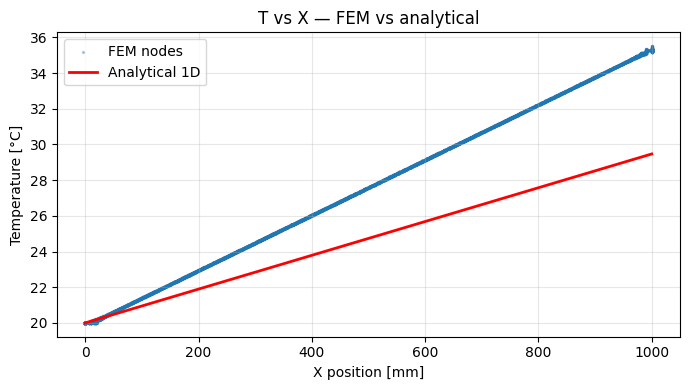

In [11]:
# Visualise the temperature field of this case
import plotly.graph_objects as go

# Cast to native float — meshio loads VTK arrays as big-endian,
# which orjson (used by plotly) cannot serialise
_c = coords.astype(float)
_T = T_field.astype(float)

fig3d = go.Figure(data=[go.Scatter3d(
    x=_c[:,0], y=_c[:,1], z=_c[:,2],
    mode='markers',
    marker=dict(size=2, color=_T, colorscale='Plasma',
                colorbar=dict(title='T [°C]', thickness=15)),
)])
fig3d.update_layout(
    title=f'FEM temperature field — {entry["case_id"]} | {params["material"]}',
    scene=dict(
        xaxis_title='X [mm]', yaxis_title='Y [mm]', zaxis_title='Z [mm]',
        aspectmode='data',
        camera=dict(eye=dict(x=2.0, y=0.5, z=0.5)),
    ),
    height=450, margin=dict(l=0, r=0, t=40, b=0),
)
fig3d.show()

# T vs X — verify linearity
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.scatter(coords[:,0], T_field, s=2, alpha=0.3, label='FEM nodes')
x_line = np.linspace(0, L, 200)
T_line = params['T_fix_C'] + q * x_line / (k * A)
ax2.plot(x_line, T_line, 'r-', linewidth=2, label='Analytical 1D')
ax2.set_xlabel('X position [mm]')
ax2.set_ylabel('Temperature [°C]')
ax2.set_title('T vs X — FEM vs analytical')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
display(fig2); plt.close(fig2)


In [12]:
# Load the full dataset and show its structure
import sys
sys.path.insert(0, str(ROOT / 'src'))
from train import load_dataset

X, Y, splits = load_dataset()

is_train = splits == 'train'
print(f"Full dataset shape  : X={X.shape},  Y={Y.shape}")
print(f"Train rows          : {is_train.sum():,}")
print(f"Test rows           : {(~is_train).sum():,}")
print()
print("Feature columns:")
names = ['x [mm]', 'y [mm]', 'z [mm]', 'q [mW]', 'k [mW/mm/°C]', 'T_fix [°C]']
for i, name in enumerate(names):
    col = X[:, i]
    print(f"  col {i}  {name:<20}  min={col.min():.3g}  max={col.max():.3g}  "
          f"mean={col.mean():.3g}  std={col.std():.3g}")
print()
print(f"Target T [°C]:  min={Y.min():.2f}  max={Y.max():.2f}  "
      f"mean={Y.mean():.2f}  std={Y.std():.2f}")

Full dataset shape  : X=(4889850, 6),  Y=(4889850, 1)
Train rows          : 4,657,000
Test rows           : 232,850

Feature columns:
  col 0  x [mm]                min=0  max=1e+03  mean=499  std=296
  col 1  y [mm]                min=0  max=100  mean=50  std=33.9
  col 2  z [mm]                min=0  max=100  mean=50  std=33.9
  col 3  q [mW]                min=100  max=5e+05  mean=2.54e+04  std=5.55e+04
  col 4  k [mW/mm/°C]          min=1.8  max=167  mean=54.7  std=59.6
  col 5  T_fix [°C]            min=20  max=20  mean=20  std=0

Target T [°C]:  min=20.00  max=45522.97  mean=325.08  std=1438.62


---
## 4. Normalisation

The network trains in **normalised space**. Raw features would cause problems:
- `q` spans 500 to 500,000 mW — a 1000× range
- `x` spans 0 to 1000 mm, while `k` spans 1.8 to 167
- Gradient descent treats all dimensions equally — huge scales dominate

### Two-step normalisation

**Step 1 — Log-transform column 3 (q):**
```python
q_norm_input = log(q_mW)
```
Why? `q` is log-spaced by design (we generated it with `logspace`). Its distribution is log-normal. A z-score on a log-normal distribution works poorly — the mean is pulled by outliers. Log-transforming first makes it roughly Gaussian.

**Step 2 — Z-score everything:**
```python
x_normalised = (x - mean) / std
```
Computed on **train only**. Test uses the same stats — this is critical to avoid data leakage.

The output `T` is also z-scored:
```python
T_normalised = (T - T_mean) / T_std
```
So the network outputs a dimensionless value, and we denormalise at inference:
```python
T_predicted = T_normalised * T_std + T_mean
```

In [13]:
from train import compute_norm_params, apply_norm

X_tr, Y_tr = X[is_train], Y[is_train]
X_va, Y_va = X[~is_train], Y[~is_train]

norm = compute_norm_params(X_tr, Y_tr)
X_tr_n, Y_tr_n = apply_norm(X_tr, Y_tr, norm)
X_va_n, Y_va_n = apply_norm(X_va, Y_va, norm)

print("Normalisation parameters (computed on train only):")
for i, name in enumerate(names):
    print(f"  col {i}  {name:<20}  mean={norm['X_mean'][i]:.4g}  std={norm['X_std'][i]:.4g}")
print(f"  Y T [°C]            mean={norm['Y_mean'][0]:.4g}  std={norm['Y_std'][0]:.4g}")

print()
print("After normalisation — all columns should be ~N(0,1):")
for i, name in enumerate(names):
    col = X_tr_n[:, i]
    print(f"  col {i}  {name:<20}  mean={col.mean():.3f}  std={col.std():.3f}")

Normalisation parameters (computed on train only):
  col 0  x [mm]                mean=499.1  std=295.7
  col 1  y [mm]                mean=49.69  std=34
  col 2  z [mm]                mean=49.71  std=33.96
  col 3  q [mW]                mean=8.868  std=1.54
  col 4  k [mW/mm/°C]          mean=51.93  std=59.01
  col 5  T_fix [°C]            mean=18.88  std=1.086
  Y T [°C]            mean=249.8  std=720.4

After normalisation — all columns should be ~N(0,1):
  col 0  x [mm]                mean=0.000  std=1.002
  col 1  y [mm]                mean=0.008  std=0.997
  col 2  z [mm]                mean=0.007  std=0.998
  col 3  q [mW]                mean=-0.003  std=1.003
  col 4  k [mW/mm/°C]          mean=0.047  std=1.011
  col 5  T_fix [°C]            mean=1.029  std=0.000


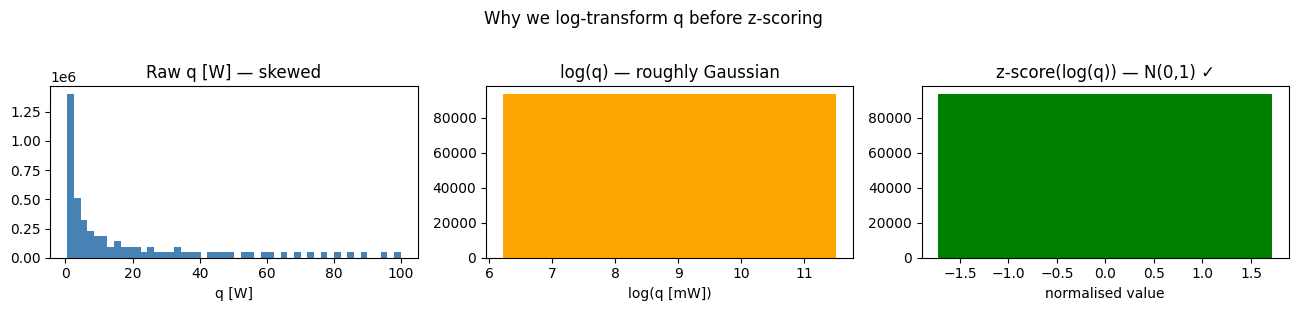

In [14]:
# Show the effect of log-transform on q
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

q_raw = X_tr[:, 3]
q_log = np.log(q_raw)
q_zscore_raw = (q_raw - q_raw.mean()) / q_raw.std()
q_zscore_log = X_tr_n[:, 3]

axes[0].hist(q_raw / 1000, bins=50, color='steelblue')
axes[0].set_title('Raw q [W] — skewed')
axes[0].set_xlabel('q [W]')

axes[1].hist(q_log, bins=50, color='orange')
axes[1].set_title('log(q) — roughly Gaussian')
axes[1].set_xlabel('log(q [mW])')

axes[2].hist(q_zscore_log, bins=50, color='green')
axes[2].set_title('z-score(log(q)) — N(0,1) ✓')
axes[2].set_xlabel('normalised value')

plt.suptitle('Why we log-transform q before z-scoring', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. The Neural Network Architecture

`ThermalNet` is a simple 4-hidden-layer MLP:

```
Input (6)  →  Linear(6→256)  →  Tanh
           →  Linear(256→256) →  Tanh
           →  Linear(256→256) →  Tanh
           →  Linear(256→256) →  Tanh
           →  Linear(256→1)
Output (1) = T_normalised
```

### Why Tanh and not ReLU?

**Critical reason**: The physics loss requires computing **second-order spatial derivatives** via autograd:

$$\frac{\partial^2 T}{\partial x^2}, \quad \frac{\partial^2 T}{\partial y^2}, \quad \frac{\partial^2 T}{\partial z^2}$$

- **ReLU**: Second derivative is **zero almost everywhere** (piecewise linear). The physics loss would always be zero — completely useless.
- **Tanh**: Smooth, infinitely differentiable. Second derivatives are well-defined and informative everywhere.

### Parameter count

In [15]:
import torch
import torch.nn as nn
sys.path.insert(0, str(ROOT / 'src'))
from arch import ThermalNet

model = ThermalNet(hidden=256)
print(model)
print()

total = 0
for name, p in model.named_parameters():
    n = p.numel()
    total += n
    print(f"  {name:<30}  shape={str(p.shape):<20}  params={n:,}")
print(f"\nTotal parameters: {total:,}")

# Quick forward pass test
dummy = torch.randn(5, 6)
out = model(dummy)
print(f"\nForward pass: input {dummy.shape} → output {out.shape}")

ThermalNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): Tanh()
    (8): Linear(in_features=256, out_features=1, bias=True)
  )
)

  net.0.weight                    shape=torch.Size([256, 6])  params=1,536
  net.0.bias                      shape=torch.Size([256])     params=256
  net.2.weight                    shape=torch.Size([256, 256])  params=65,536
  net.2.bias                      shape=torch.Size([256])     params=256
  net.4.weight                    shape=torch.Size([256, 256])  params=65,536
  net.4.bias                      shape=torch.Size([256])     params=256
  net.6.weight                    shape=torch.Size([256, 256])  params=65,536
  net.6.bias                      shape=torch.Size([256])     

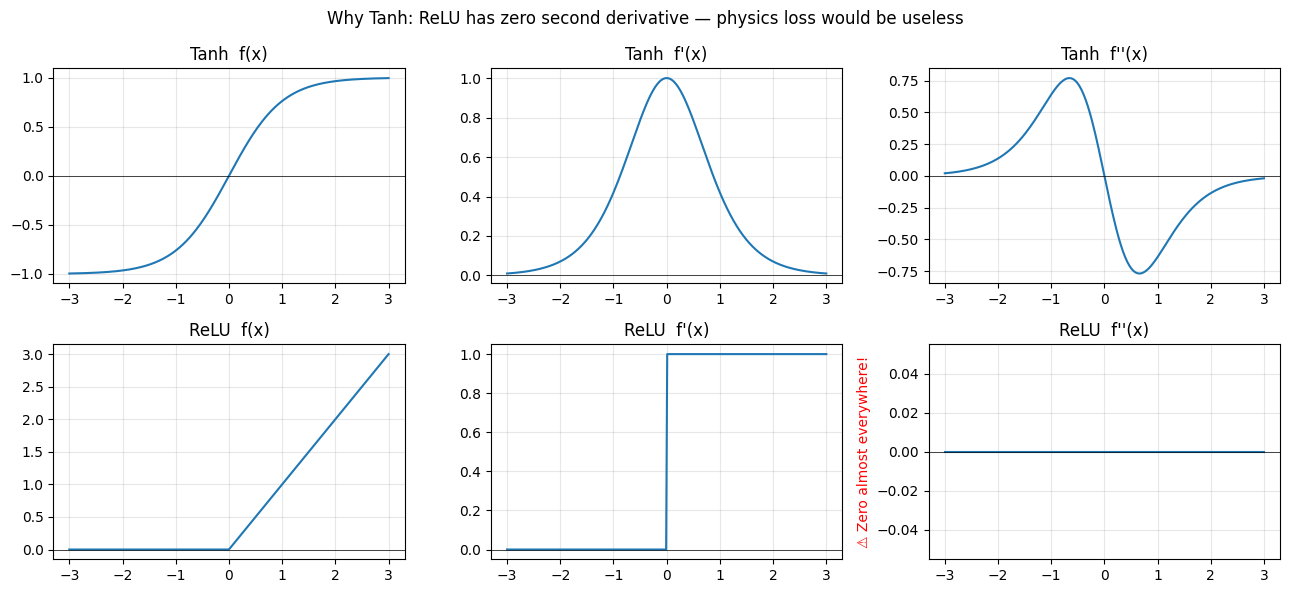

In [16]:
# Visualise the Tanh vs ReLU second derivative problem
x = torch.linspace(-3, 3, 300, requires_grad=True)

# Tanh
y_tanh = torch.tanh(x)
dy_tanh = torch.autograd.grad(y_tanh.sum(), x, create_graph=True)[0]
d2y_tanh = torch.autograd.grad(dy_tanh.sum(), x)[0]

x2 = torch.linspace(-3, 3, 300, requires_grad=True)
y_relu = torch.relu(x2)
dy_relu = torch.autograd.grad(y_relu.sum(), x2, create_graph=True)[0]
d2y_relu = torch.autograd.grad(dy_relu.sum(), x2)[0]

x_np = x.detach().numpy()
fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for row, (name, y, dy, d2y) in enumerate([
    ('Tanh', y_tanh.detach(), dy_tanh.detach(), d2y_tanh.detach()),
    ('ReLU', y_relu.detach(), dy_relu.detach(), d2y_relu.detach()),
]):
    axes[row, 0].plot(x_np, y.numpy()); axes[row, 0].set_title(f'{name}  f(x)')
    axes[row, 1].plot(x_np, dy.numpy()); axes[row, 1].set_title(f'{name}  f\'(x)')
    axes[row, 2].plot(x_np, d2y.numpy()); axes[row, 2].set_title(f'{name}  f\'\'(x)')
    for ax in axes[row]: ax.grid(alpha=0.3); ax.axhline(0, color='k', lw=0.5)

axes[1, 2].set_ylabel('⚠ Zero almost everywhere!', color='red', fontsize=10)
plt.suptitle('Why Tanh: ReLU has zero second derivative — physics loss would be useless')
plt.tight_layout()
plt.show()

---
## 6. The Physics Loss

This is the PINN part. We enforce the PDE $\nabla^2 T = 0$ directly via autograd.

### The challenge: normalised coordinates

The network operates in normalised space $\hat{x} = (x - \mu_x)/\sigma_x$, but the PDE lives in physical space $x$ [mm]. We must scale the derivatives correctly.

By the **chain rule**:

$$\frac{\partial T_{phys}}{\partial x_j} = \frac{\partial \hat{T}}{\partial \hat{x}_j} \cdot \frac{\sigma_T}{\sigma_{x_j}}$$

$$\frac{\partial^2 T_{phys}}{\partial x_j^2} = \frac{\partial^2 \hat{T}}{\partial \hat{x}_j^2} \cdot \frac{\sigma_T}{\sigma_{x_j}^2}$$

So the Laplacian in physical units is:

$$\nabla^2 T_{phys} = \sum_{j=0}^{2} \underbrace{\frac{\partial^2 \hat{T}}{\partial \hat{x}_j^2}}_{\text{autograd}} \cdot \frac{\sigma_T}{\sigma_{x_j}^2}$$

The loss is the **mean squared Laplacian residual**:

$$\mathcal{L}_{phys} = \frac{1}{N} \sum_i \left(\nabla^2 T^{(i)}_{phys}\right)^2$$

### Why this scaling matters

Without scaling, the physics loss would have arbitrary magnitude depending on the coordinate units (mm vs m vs km). The scaling makes it **unit-invariant** and keeps $\lambda_{phys} = 0.1$ a meaningful ratio.

In [17]:
from losses import physics_loss

# Load norm params as tensors
device = 'cpu'
npt = {k: torch.tensor(v, dtype=torch.float32) for k, v in norm.items()}

# Show what the physics loss computation looks like step by step
model.eval()

# Take a small batch
x_batch = torch.tensor(X_tr_n[:32], dtype=torch.float32).requires_grad_(True)

# Forward pass
T_pred = model(x_batch)  # (32, 1) in normalised space

# First derivatives wrt x, y, z (columns 0, 1, 2)
g = torch.autograd.grad(T_pred.sum(), x_batch, create_graph=True)[0][:, :3]  # (32, 3)
print("First-order gradients shape:", g.shape)
print("∂T̂/∂x̂  (normalised space):", g[:5, 0].detach().numpy())

# Second derivatives (diagonal Hessian)
sx = npt['X_std'][:3]   # std of x, y, z
sy = npt['Y_std']        # std of T

lap = torch.zeros(32)
for j in range(3):
    H_j = torch.autograd.grad(g[:, j].sum(), x_batch, create_graph=True)[0][:, j]
    contribution = H_j * sy.squeeze() / (sx[j] ** 2)
    print(f"  ∂²T/∂x_{j}² (physical, scaled):  mean={contribution.detach().mean():.4f}")
    lap = lap + contribution.detach()

print(f"\nLaplacian residual (should be ~0):  mean={lap.mean():.6f},  std={lap.std():.6f}")
print(f"Physics loss = mean(lap²) = {(lap**2).mean().item():.6f}")

First-order gradients shape: torch.Size([32, 3])
∂T̂/∂x̂  (normalised space): [0.00656899 0.02526987 0.01348865 0.03318116 0.03416768]
  ∂²T/∂x_0² (physical, scaled):  mean=0.0001
  ∂²T/∂x_1² (physical, scaled):  mean=0.0032
  ∂²T/∂x_2² (physical, scaled):  mean=0.0031

Laplacian residual (should be ~0):  mean=0.006318,  std=0.004394
Physics loss = mean(lap²) = 0.000059


In [18]:
# Compare physics loss on an untrained vs trained model
import os

x_phys = torch.tensor(X_tr_n[:256], dtype=torch.float32)

# Untrained
fresh_model = ThermalNet(hidden=256)
loss_untrained = physics_loss(fresh_model, x_phys, npt)
print(f"Physics loss (random weights) : {loss_untrained.item():.6f}")

# Trained
ckpt_path = ROOT / 'saves' / 'thermal_pinn.pt'
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    trained_model = ThermalNet(hidden=ckpt['hidden'])
    trained_model.load_state_dict(ckpt['model_state'])
    loss_trained = physics_loss(trained_model, x_phys, npt)
    print(f"Physics loss (trained model)  : {loss_trained.item():.6f}")
    ratio = loss_untrained.item() / max(loss_trained.item(), 1e-10)
    print(f"\nImprovement factor: {ratio:.1f}× lower after training")
else:
    print("No trained model found — run train.py first")

Physics loss (random weights) : 0.000059
Physics loss (trained model)  : 0.000000

Improvement factor: 21974.8× lower after training


---
## 7. The Training Loop

### Combined loss

$$\mathcal{L}_{total} = \underbrace{\mathcal{L}_{data}}_{\text{fit FEM}} + \lambda \cdot \underbrace{\mathcal{L}_{phys}}_{\text{enforce PDE}}$$

Where:
- $\mathcal{L}_{data} = \text{MSE}(\hat{T}_{pred}, \hat{T}_{FEM})$ — supervised on FEM ground truth
- $\mathcal{L}_{phys}$ — physics residual (previous section)
- $\lambda = 0.1$ — weight balancing the two losses

### Training details

| Setting | Value | Reason |
|---------|-------|--------|
| Epochs | 20 | Fast baseline (likely undertrained) |
| Batch size | 4094 | Large batch — stable gradients |
| Physics batch | 256 | Subset — Hessian is expensive |
| LR | 1e-3 | Adam default |
| LR decay | ×0.5 every 30 epochs | StepLR |
| Grad clipping | norm=1.0 | Prevents explosion with physics loss |
| Save criterion | best val MSE | Model checkpoint |

### Important implementation detail

```python
loss_phys = physics_loss(model, xb[:phys_bs].detach(), npt)
#                                           ^^^^^^^^
#  .detach() separates the physics graph from the data graph
#  so their backward passes don't interfere
```

In [20]:
# Walk through one training step manually
import torch.nn as nn

device = 'cpu'
model = ThermalNet(hidden=256).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
lambda_phys = 0.1
phys_bs = 256

# One mini-batch
xb = torch.tensor(X_tr_n[:512], dtype=torch.float32).to(device)
yb = torch.tensor(Y_tr_n[:512], dtype=torch.float32).to(device)

# Forward
model.train()
pred = model(xb)                                             # (512, 1)
loss_data = criterion(pred, yb)                              # scalar
loss_phys = physics_loss(model, xb[:phys_bs].detach(), npt) # scalar
loss_total = loss_data + lambda_phys * loss_phys

print(f"loss_data   (MSE, normalised T) : {loss_data.item():.6f}")
print(f"loss_phys   (Laplacian residual): {loss_phys.item():.6f}")
print(f"lambda * phys                   : {lambda_phys * loss_phys.item():.6f}")
print(f"loss_total                      : {loss_total.item():.6f}")

# Backward
optimiser.zero_grad()
loss_total.backward()

# Grad norms before clipping
total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
print(f"\nGradient norm (before clip): {total_norm:.4f}")

optimiser.step()
print("Step done ✓")

loss_data   (MSE, normalised T) : 0.053916
loss_phys   (Laplacian residual): 0.000020
lambda * phys                   : 0.000002
loss_total                      : 0.053918

Gradient norm (before clip): 1.2516
Step done ✓


In [21]:
# Run a short training for demonstration (5 epochs)
from torch.utils.data import DataLoader, TensorDataset

model = ThermalNet(hidden=256)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.MSELoss()

loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_n), torch.tensor(Y_tr_n)),
    batch_size=4094, shuffle=True
)

history = {'data': [], 'phys': [], 'val_mae': []}
X_va_t = torch.tensor(X_va_n)
Y_va_t = torch.tensor(Y_va_n)

print(f"{'Epoch':>5}  {'Data MSE':>10}  {'Phys loss':>10}  {'Val MAE [°C]':>13}")
print('-' * 45)

for epoch in range(1, 6):
    model.train()
    ep_data, ep_phys = 0.0, 0.0
    for xb, yb in loader:
        pred = model(xb)
        ld = crit(pred, yb)
        lp = physics_loss(model, xb[:256].detach(), npt)
        loss = ld + 0.1 * lp
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        ep_data += ld.item() * len(xb); ep_phys += lp.item()
    ep_data /= len(X_tr_n); ep_phys /= len(loader)

    model.eval()
    with torch.no_grad():
        pv = model(X_va_t).numpy() * norm['Y_std'] + norm['Y_mean']
        tv = Y_va_t.numpy() * norm['Y_std'] + norm['Y_mean']
        mae = np.abs(pv - tv).mean()

    history['data'].append(ep_data); history['phys'].append(ep_phys)
    history['val_mae'].append(mae)
    print(f"{epoch:5d}  {ep_data:10.6f}  {ep_phys:10.6f}  {mae:13.4f}")

Epoch    Data MSE   Phys loss   Val MAE [°C]
---------------------------------------------
    1    0.043928    0.001410       897.3636
    2    0.003510    0.000233       944.2562
    3    0.002061    0.000093       951.6522
    4    0.000910    0.000047       984.7604
    5    0.000189    0.000026      1034.1786


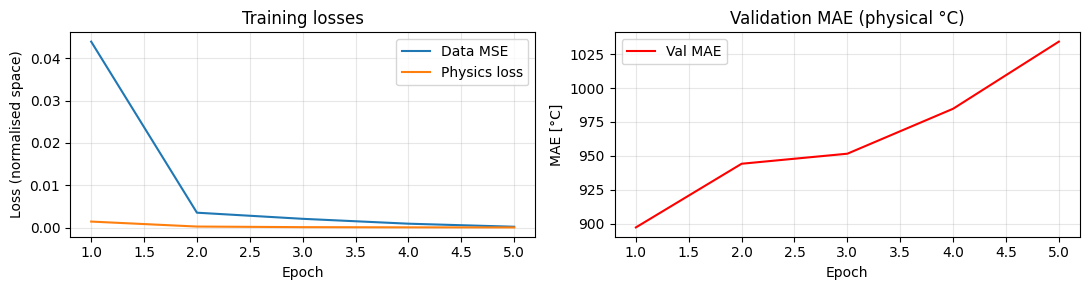

In [22]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

epochs = range(1, len(history['data']) + 1)
axes[0].plot(epochs, history['data'], label='Data MSE')
axes[0].plot(epochs, history['phys'], label='Physics loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (normalised space)')
axes[0].set_title('Training losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_mae'], color='red', label='Val MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE [°C]')
axes[1].set_title('Validation MAE (physical °C)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Inference & Results

Inference for one case:

```
VTK  →  coords (N, 3)  +  case_params.json
                ↓
build_features  →  X (N, 6)    [x, y, z, q, k, T_fix]
                ↓
normalise_X     →  X_norm (N, 6)
                ↓
model(X_norm)   →  T_norm (N, 1)
                ↓
denormalise     →  T_pred [°C] (N,)
```

In [23]:
from inference import load_model, load_norm_params, build_features, normalise_X, predict, compute_metrics

if (ROOT / 'saves' / 'thermal_pinn.pt').exists():
    trained_model = load_model()
    norm_p = load_norm_params()

    # Pick an interpolation test case (within training Q range 500 mW–100 kW)
    test_entries = [e for e in manifest['cases'] if e.get('split') == 'test' and e.get('success')]
    entry = next(e for e in test_entries if 500 <= e['q_total_mW'] <= 100_000)

    vtk_path = CASES_DIR / entry['vtk']
    params = json.loads((vtk_path.parent / 'case_params.json').read_text())
    mesh = meshio.read(str(vtk_path))
    coords = mesh.points
    temp_key = next(k for k in mesh.point_data if k.lower() == 'temperature')
    true_C = mesh.point_data[temp_key].squeeze()

    X_n = normalise_X(build_features(coords, params), norm_p)
    pred_C = predict(trained_model, X_n, norm_p)

    m = compute_metrics(pred_C, true_C)
    k_val = MATERIAL_K.get(params['material'])

    print(f"Case     : {entry['case_id']}  [{params['split']}]")
    print(f"Material : {params['material']}  (k={k_val} W/m/K)")
    print(f"Q        : {params['q_total_mW']/1000:.1f} W")
    print(f"T_fix    : {params['T_fix_C']} °C")
    print()
    print(f"FEM  T_max  : {true_C.max():.2f} °C")
    print(f"Pred T_max  : {pred_C.max():.2f} °C")
    print()
    print(f"MAE         : {m['mae']:.4f} °C")
    print(f"RMSE        : {m['rmse']:.4f} °C")
    print(f"Relative err: {m['rel_err']:.2f} %")
else:
    print("No trained model found — run src/train.py first")

Case     : case_0102  [test]
Material : Steel_A36  (k=50.0 W/m/K)
Q        : 52.5 W
T_fix    : 20.0 °C

FEM  T_max  : 192.00 °C
Pred T_max  : 187.10 °C

MAE         : 4.1689 °C
RMSE        : 4.3654 °C
Relative err: 4.96 %


In [24]:
# Three-panel comparison with toggle buttons: FEM | Prediction | Error
if (ROOT / 'saves' / 'thermal_pinn.pt').exists():
    import plotly.graph_objects as go

    vmin, vmax = true_C.min(), true_C.max()
    err = np.abs(pred_C - true_C)
    x, y, z = coords[:, 0].astype(float), coords[:, 1].astype(float), coords[:, 2].astype(float)
    true_C = true_C.astype(float)
    pred_C = pred_C.astype(float)
    err    = err.astype(float)

    panels = [
        (true_C, 'FEM (ground truth)',    'Plasma', vmin,      vmax,      'T [°C]'),
        (pred_C, 'ThermalNet prediction', 'Plasma', vmin,      vmax,      'T [°C]'),
        (err,    'Absolute error |ΔT|',   'Reds',   0,         err.max(), '|ΔT| [°C]'),
    ]

    scene_cfg = dict(
        xaxis_title='X [mm]', yaxis_title='Y [mm]', zaxis_title='Z [mm]',
        aspectmode='data',
        camera=dict(eye=dict(x=2.0, y=0.5, z=0.5)),
    )

    # One trace per panel — only the active one is visible
    traces = []
    for i, (data, title, cmap, cmin, cmax, clabel) in enumerate(panels):
        traces.append(go.Scatter3d(
            x=x, y=y, z=z,
            mode='markers',
            name=title,
            visible=(i == 0),   # only FEM visible by default
            marker=dict(
                size=2, color=data, colorscale=cmap, cmin=cmin, cmax=cmax,
                colorbar=dict(title=clabel, thickness=14),
                showscale=True,
            ),
        ))

    # One button per panel — sets visibility=[False, False, False] then flips one True
    buttons = []
    for i, (_, title, _, _, _, _) in enumerate(panels):
        visibility = [j == i for j in range(len(panels))]
        buttons.append(dict(
            label=title,
            method='update',
            args=[
                {'visible': visibility},
                {'title': (
                    f"{entry['case_id']}  |  Q={params['q_total_mW']/1000:.1f} W  "
                    f"mat={params['material']}  |  {title}"
                )},
            ],
        ))

    fig3d = go.Figure(data=traces)
    fig3d.update_layout(
        title=(
            f"{entry['case_id']}  |  Q={params['q_total_mW']/1000:.1f} W  "
            f"mat={params['material']}  k={k_val} W/m/K  |  "
            f"MAE={m['mae']:.2f}°C  RelErr={m['rel_err']:.1f}%"
        ),
        scene=scene_cfg,
        updatemenus=[dict(
            type='buttons',
            direction='right',
            x=0.5, xanchor='center',
            y=1.12, yanchor='top',
            buttons=buttons,
            showactive=True,
        )],
        height=550,
        margin=dict(l=0, r=0, t=100, b=0),
    )
    fig3d.show()


In [25]:
# Run all test cases and compare performance
if (ROOT / 'saves' / 'thermal_pinn.pt').exists():
    from inference import run_case
    vtk_entries = {e['case_id']: e for e in manifest['cases'] if e.get('success')}
    test_ids = [e['case_id'] for e in manifest['cases'] if e.get('split') == 'test' and e.get('success')]

    results = []
    for cid in test_ids:
        entry = vtk_entries[cid]
        vtk_path = CASES_DIR / entry['vtk']
        params = json.loads((vtk_path.parent / 'case_params.json').read_text())
        mesh = meshio.read(str(vtk_path))
        coords = mesh.points
        temp_key = next(k for k in mesh.point_data if k.lower() == 'temperature')
        true_C = mesh.point_data[temp_key].squeeze()
        X_n = normalise_X(build_features(coords, params), norm_p)
        pred_C = predict(trained_model, X_n, norm_p)
        m = compute_metrics(pred_C, true_C)
        results.append({
            'case_id': cid, 'material': params['material'],
            'q_W': params['q_total_mW'] / 1000,
            'T_max_fem': true_C.max(), 'T_max_pred': pred_C.max(),
            **m
        })

    import pandas as pd
    df = pd.DataFrame(results).sort_values(['material', 'q_W'])
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(df[['case_id', 'material', 'q_W', 'T_max_fem', 'T_max_pred', 'mae', 'rmse', 'rel_err']].to_string(index=False))

  case_id         material    q_W  T_max_fem  T_max_pred      mae     rmse  rel_err
case_0310   Aluminium_6061   0.10      20.10       16.78     3.86     3.87  8059.11
case_0311   Aluminium_6061   0.30      20.29       17.66     3.45     3.48  2398.71
case_0312   Aluminium_6061  52.50      71.50       71.41     4.23     4.36    16.83
case_0313   Aluminium_6061 200.00     216.18      113.45    33.02    45.49    34.45
case_0314   Aluminium_6061 500.00     510.45      118.36   163.70   204.35    68.32
case_0520     Concrete_C30   0.10      29.10       30.81     4.01     5.64    90.30
case_0521     Concrete_C30   0.30      47.30       47.25     3.64     4.50    27.31
case_0522     Concrete_C30  52.50    4797.81     4712.64    28.59    33.55     1.22
case_0523     Concrete_C30 200.00   18221.19    11103.39  2493.08  3798.15    28.04
case_0524     Concrete_C30 500.00   45522.97    13629.06 12818.41 16511.15    57.66
case_0100        Steel_A36   0.10      20.33       16.68     4.21     4.24  

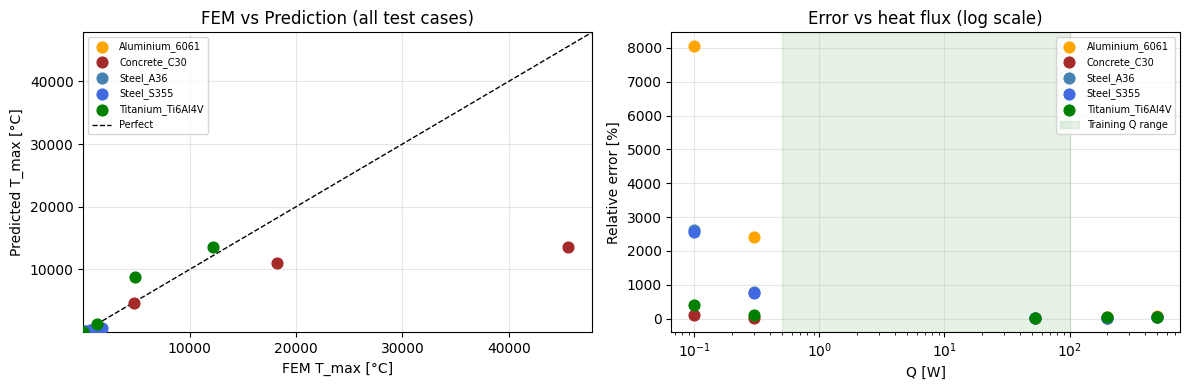

In [26]:
# Scatter: FEM T_max vs Predicted T_max across all test cases
%matplotlib inline
if (ROOT / 'saves' / 'thermal_pinn.pt').exists():
    mat_colors = {
        'Steel_A36': 'steelblue', 'Steel_S355': 'royalblue',
        'Aluminium_6061': 'orange', 'Titanium_Ti6Al4V': 'green', 'Concrete_C30': 'brown'
    }
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for mat, grp in df.groupby('material'):
        c = mat_colors.get(mat, 'gray')
        axes[0].scatter(grp['T_max_fem'], grp['T_max_pred'], label=mat, color=c, s=60, zorder=3)
        axes[1].scatter(grp['q_W'], grp['rel_err'], label=mat, color=c, s=60, zorder=3)

    T_all = list(df['T_max_fem']) + list(df['T_max_pred'])
    lims = [min(T_all) * 0.95, max(T_all) * 1.05]
    axes[0].plot(lims, lims, 'k--', lw=1, label='Perfect')
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel('FEM T_max [°C]'); axes[0].set_ylabel('Predicted T_max [°C]')
    axes[0].set_title('FEM vs Prediction (all test cases)')
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    axes[1].axvspan(0.5, 100, alpha=0.1, color='green', label='Training Q range')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Q [W]'); axes[1].set_ylabel('Relative error [%]')
    axes[1].set_title('Error vs heat flux (log scale)')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 9. Weaknesses & What to Improve

### Issues in the current implementation

| Issue | Location | Effect | Fix |
|-------|----------|--------|-----|
| Only 20 epochs | `train.py:CONFIG` | Likely undertrained | Increase to 200–500 |
| Physics loss on 256 rows only per batch | `train.py:257` | Sparse PDE coverage | Use full batch or separate collocation points |
| No LR warmup | `train.py` | Early instability | Add warmup scheduler |
| Relative error metric uses `mean(T-T_min)` | `inference.py:113` | Inflates error for near-uniform fields | Use `mean(|T|)` or `(T_max - T_min)` |
| `loss_phys` uses `.detach()` | `train.py:257` | Physics and data gradients fully decoupled | Fine in most cases, but loses cross-gradient info |
| Single fixed `T_fix=20°C` | `scripts/03` | No generalisation over BC temperature | Vary T_fix |

### Why extrapolation fails

For Q outside the training range, the normalised input `log(q)` falls outside the region the model has seen. The network can interpolate well but extrapolates poorly — this is fundamental to all MLPs, not specific to this implementation. The physics loss helps regularise but cannot fully compensate.

### What the ThermoMech project fixes

The new `Beam_FEM_ThermoMech` project addresses the architectural limitations:
- Multi-task learning (thermal + structural auxiliary tasks help regularise)
- Shared encoder learns richer representations
- Coupled physics loss links the thermal and mechanical fields correctly

In [27]:
# Show extrapolation failure visually
if (ROOT / 'saves' / 'thermal_pinn.pt').exists():
    interp = df[df['q_W'].between(0.5, 100)]
    extrap_lo = df[df['q_W'] < 0.5]
    extrap_hi = df[df['q_W'] > 100]

    print("Interpolation (Q in training range 0.5–100 W):")
    if not interp.empty:
        print(f"  Mean relative error : {interp['rel_err'].mean():.1f} %")
        print(f"  Mean MAE            : {interp['mae'].mean():.2f} °C")
    else:
        print("  (no test cases in training range)")

    print("\nExtrapolation below (Q < 0.5 W):")
    if not extrap_lo.empty:
        print(f"  Mean relative error : {extrap_lo['rel_err'].mean():.1f} %")
        print(f"  Mean MAE            : {extrap_lo['mae'].mean():.2f} °C")

    print("\nExtrapolation above (Q > 100 W):")
    if not extrap_hi.empty:
        print(f"  Mean relative error : {extrap_hi['rel_err'].mean():.1f} %")
        print(f"  Mean MAE            : {extrap_hi['mae'].mean():.2f} °C")

Interpolation (Q in training range 0.5–100 W):
  Mean relative error : 6.0 %
  Mean MAE            : 10.65 °C

Extrapolation below (Q < 0.5 W):
  Mean relative error : 1783.3 %
  Mean MAE            : 4.00 °C

Extrapolation above (Q > 100 W):
  Mean relative error : 46.2 %
  Mean MAE            : 2054.39 °C
